# Crypto and Stablecoin Liquidity Pulse

This notebook asks whether BTC/ETH price residuals line up with current stablecoin liquidity context. It is a market-structure read, not a trading model.

The output is a CoinGecko source card, price decomposition, edge-trimmed residual events, and a current DeFiLlama stablecoin chain context table.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Fetch BTC and ETH market charts


In [2]:
coins = ["bitcoin", "ethereum"]
frames = [fetch_coingecko_market_chart(c, days=365) for c in coins]
prices = pd.concat(frames, ignore_index=True)
prices.head(20)


,date,coin_id,price,source,data_quality
0,2025-05-23,bitcoin,111560.356938,CoinGecko API,public_api_snapshot
1,2025-05-24,bitcoin,107216.668569,CoinGecko API,public_api_snapshot
2,2025-05-25,bitcoin,107831.363744,CoinGecko API,public_api_snapshot
3,2025-05-26,bitcoin,108861.810377,CoinGecko API,public_api_snapshot
4,2025-05-27,bitcoin,109377.715133,CoinGecko API,public_api_snapshot
5,2025-05-28,bitcoin,109068.456949,CoinGecko API,public_api_snapshot
6,2025-05-29,bitcoin,107838.184311,CoinGecko API,public_api_snapshot
7,2025-05-30,bitcoin,105745.416604,CoinGecko API,public_api_snapshot
8,2025-05-31,bitcoin,104010.919562,CoinGecko API,public_api_snapshot
9,2025-06-01,bitcoin,104687.507429,CoinGecko API,public_api_snapshot


## 2. Source card and price audit


In [3]:
audit = source_audit_table(prices, value_col="price", entity_col="coin_id", time_col="date")
source_card = pd.DataFrame([{
    "source": "CoinGecko API",
    "endpoint": "https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart",
    "access_date": pd.Timestamp.today().date().isoformat(),
    "query_params": f"coins={','.join(coins)}; vs_currency=usd; days=365",
    "time_range": f"{prices['date'].min()} to {prices['date'].max()}",
    "cache_path": "not cached; outputs saved to examples/hot_trends/outputs",
    "interpretation_scope": "public BTC/ETH price history for market-structure context; not a trading signal",
}])
display(source_card)
audit


,source,endpoint,access_date,query_params,time_range,cache_path,interpretation_scope
0,CoinGecko API,https://api.coingecko.com/api/v3/coins/{coin_i...,2026-05-22,"coins=bitcoin,ethereum; vs_currency=usd; days=365",2025-05-23 to 2026-05-22,not cached; outputs saved to examples/hot_tren...,public BTC/ETH price history for market-struct...


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,bitcoin,2025-05-23 00:00:00,2026-05-22 00:00:00,366,0.0,62853.690384,124773.508231
1,ethereum,2025-05-23 00:00:00,2026-05-22 00:00:00,366,0.0,1820.569322,4829.225542


## 3. Decompose crypto price series


In [4]:
components = decompose_table(prices, entity_col="coin_id", time_col="date", value_col="price", method="MA_BASELINE", period=7, trend_window=21, transform="log")
summary = editorial_priority(component_summary(components, entity_col="coin_id", time_col="date"), entity_col="coin_id")
summary


,coin_id,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
1,ethereum,366,2025-05-23 00:00:00,2026-05-22 00:00:00,4.024828,-0.001398,-2.723404,0.523068,64.310751,MA_BASELINE,1.0,1.0,0.5,0.775
0,bitcoin,366,2025-05-23 00:00:00,2026-05-22 00:00:00,5.901470,-0.001547,-14.428352,0.770613,125.749236,MA_BASELINE,0.5,0.5,1.0,0.725


## Visualization: crypto price components

The left panels plot transformed observed price and trend by coin. The right panels plot residuals from the smooth baseline. Large bars mark dates for follow-up research; they are not entry or exit rules.


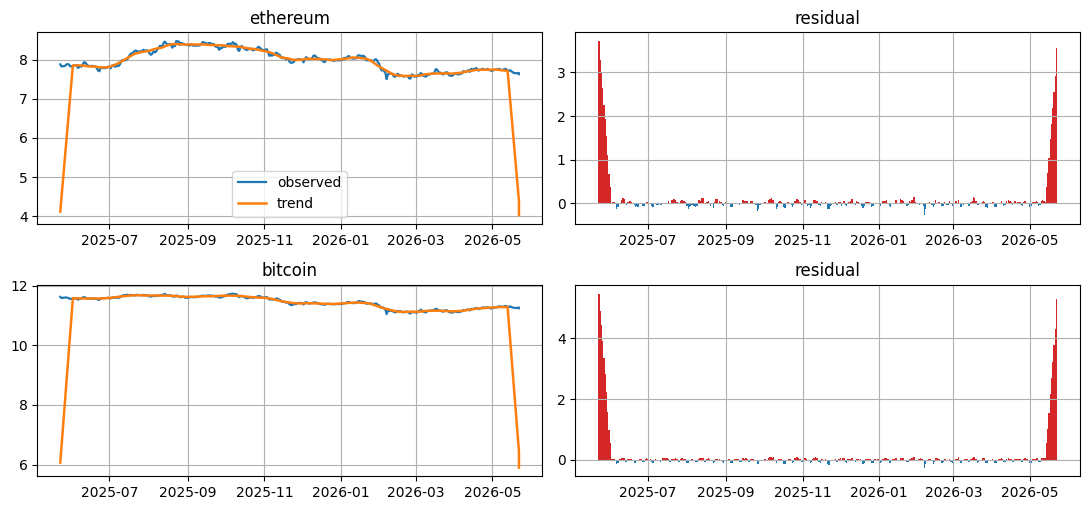

In [5]:
coins_to_plot = summary["coin_id"].tolist()
fig, axes = plt.subplots(len(coins_to_plot), 2, figsize=(11, max(3.0, 2.6 * len(coins_to_plot))), squeeze=False)
for row, coin_id in enumerate(coins_to_plot):
    panel = components.loc[components["coin_id"].eq(coin_id)].sort_values("date").copy()
    panel["date"] = pd.to_datetime(panel["date"])
    axes[row, 0].plot(panel["date"], panel["observed"], label="observed", linewidth=1.6)
    axes[row, 0].plot(panel["date"], panel["trend"], label="trend", linewidth=1.8)
    axes[row, 0].set_title(coin_id)
    axes[row, 1].bar(panel["date"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"), width=1.0)
    axes[row, 1].set_title("residual")
axes[0, 0].legend(loc="best")
plt.tight_layout()
plt.show()


## 4. Residual events


In [6]:
events = residual_event_table(components, entity_col="coin_id", time_col="date", top_n=20, trim_edges=21)
events


,date,coin_id,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2026-02-06,bitcoin,11.048565,11.217366,0.080617,-0.249418,-5.836389,5.836389,MA_BASELINE
1,2026-02-06,ethereum,7.506905,7.724144,0.052559,-0.269798,-4.931441,4.931441,MA_BASELINE
2,2025-11-22,bitcoin,11.351016,11.423804,0.079376,-0.152163,-3.705549,3.705549,MA_BASELINE
3,2025-11-21,bitcoin,11.369632,11.433564,0.080617,-0.144549,-3.538715,3.538715,MA_BASELINE
4,2025-09-26,bitcoin,11.598769,11.656836,0.080617,-0.138685,-3.410229,3.410229,MA_BASELINE
5,2025-09-27,bitcoin,11.605598,11.660556,0.079376,-0.134334,-3.314907,3.314907,MA_BASELINE
6,2025-10-18,bitcoin,11.575371,11.630168,0.079376,-0.134173,-3.311382,3.311382,MA_BASELINE
7,2025-10-17,bitcoin,11.590597,11.634392,0.080617,-0.124412,-3.097521,3.097521,MA_BASELINE
8,2026-02-13,bitcoin,11.100203,11.143801,0.080617,-0.124215,-3.093204,3.093204,MA_BASELINE
9,2025-09-26,ethereum,8.259216,8.371748,0.052559,-0.165091,-3.043532,3.043532,MA_BASELINE


## 5. Fetch current stablecoin context from DeFiLlama

This cell reads the current DeFiLlama stablecoin endpoint schema and records the table used for the liquidity context. It does not measure historical stablecoin-supply change.


In [7]:
stablecoin_source_card = pd.DataFrame([{
    "source": "DeFiLlama stablecoin API",
    "endpoint": "https://stablecoins.llama.fi/stablecoins?includePrices=true",
    "access_date": pd.Timestamp.today().date().isoformat(),
    "query_params": "includePrices=true",
    "time_range": "current endpoint snapshot",
    "cache_path": "not cached; outputs saved to examples/hot_trends/outputs",
    "interpretation_scope": "current stablecoin chain supply context; not executable liquidity or a trading signal",
}])
stable_chains = fetch_defillama_stablecoin_chains()
display(stablecoin_source_card)
stable_chains.head(20)


,source,endpoint,access_date,query_params,time_range,cache_path,interpretation_scope
0,DeFiLlama stablecoin API,https://stablecoins.llama.fi/stablecoins?inclu...,2026-05-22,includePrices=true,current endpoint snapshot,not cached; outputs saved to examples/hot_tren...,current stablecoin chain supply context; not e...


,totalCirculatingUSD,name
0,{'peggedUSD': 7231293.297661571},Manta
1,{'peggedUSD': 475472.9230870892},ThunderCore
2,{'peggedUSD': 39708611.36492221},Movement
3,{'peggedUSD': 32717.41461544214},Shiden
4,{'peggedUSD': 138869.81749023663},Corn
5,{'peggedUSD': 346081964.99845433},Starknet
6,"{'peggedUSD': 90328483811.95787, 'peggedREAL':...",Tron
7,{'peggedUSD': 3539355.889837592},CORE
8,{'peggedUSD': 285081.514346732},ApeChain
9,"{'peggedUSD': 3776681.058702138, 'peggedSGD': ...",Zilliqa


## Visualization: current stablecoin chain context

The x-axis is current pegged USD by chain from DeFiLlama. Use it to size the liquidity backdrop around BTC/ETH residual dates; do not read it as historical flow or available execution depth.


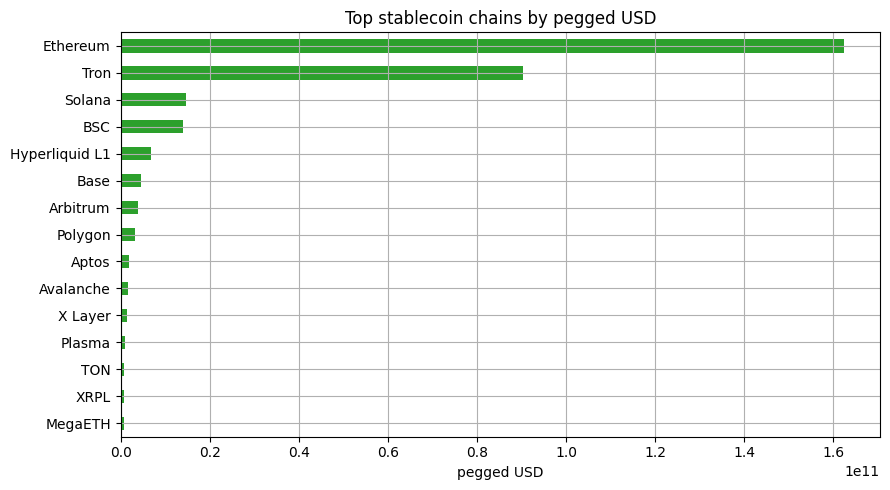

In [8]:
def _pegged_usd(value):
    if isinstance(value, dict):
        return float(value.get("peggedUSD") or 0.0)
    return float(value or 0.0)

stable_context = stable_chains.assign(pegged_usd=stable_chains["totalCirculatingUSD"].map(_pegged_usd))
stable_context = stable_context.sort_values("pegged_usd", ascending=False).head(15).sort_values("pegged_usd")
ax = stable_context.plot(kind="barh", x="name", y="pegged_usd", figsize=(9, 5), color="tab:green", legend=False, title="Top stablecoin chains by pegged USD")
ax.set_xlabel("pegged USD")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Publication language


In [9]:
phrasing = article_publication_phrasing()
phrasing


,draft_claim,evidence_based_phrasing
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy interpre...
2,This repo is winning because stars are rising.,Star velocity measures developer attention for...
3,This pageview spike shows the topic matters most.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [10]:
save_table(source_card, "06_coingecko_source_card")
save_table(stablecoin_source_card, "06_defillama_source_card")
save_table(audit, "06_crypto_price_audit")
save_table(summary, "06_crypto_price_summary")
save_table(events, "06_crypto_price_residual_events")
save_table(stable_chains, "06_defillama_stablecoin_context")
save_table(phrasing, "06_crypto_publication_phrasing")


saved: examples/hot_trends/outputs/06_coingecko_source_card.csv
saved: examples/hot_trends/outputs/06_defillama_source_card.csv
saved: examples/hot_trends/outputs/06_crypto_price_audit.csv
saved: examples/hot_trends/outputs/06_crypto_price_summary.csv
saved: examples/hot_trends/outputs/06_crypto_price_residual_events.csv
saved: examples/hot_trends/outputs/06_defillama_stablecoin_context.csv
saved: examples/hot_trends/outputs/06_crypto_publication_phrasing.csv
